In [24]:
#1
!pip install easyocr -q

In [25]:
#2
import easyocr
import torch
import cv2
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [26]:
#3
def visualize_ocr(image_path, results, figsize=(12, 8)):
    '''Vẽ bounding box + text nhận diện được lên ảnh gốc.'''
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for (bbox, text, conf) in results:
        tl = tuple(map(int, bbox[0]))
        br = tuple(map(int, bbox[2]))
        cv2.rectangle(image, tl, br, (255, 0, 0), 2)
        cv2.putText(image, f"{text} ({conf:.2f})", (tl[0], max(tl[1] - 10, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.show()


def ocr_pipeline(image_path, languages=['vi', 'en'], gpu=None, **kwargs):
    if gpu is None:
        gpu = torch.cuda.is_available()
    reader = easyocr.Reader(languages, gpu=gpu)
    results = reader.readtext(image_path, **kwargs)
    visualize_ocr(image_path, results)
    return results

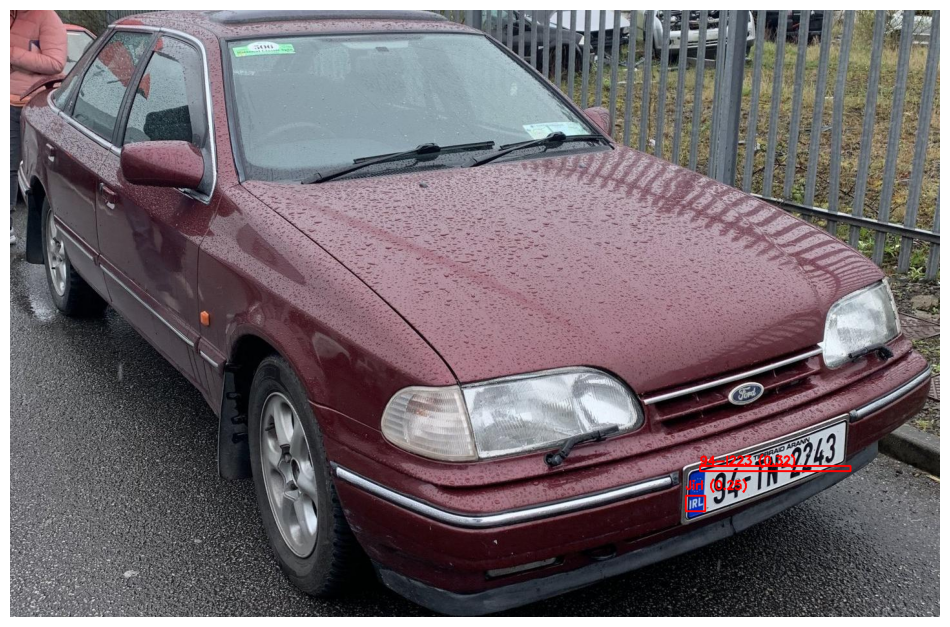


--- KẾT QUẢ TRÍCH XUẤT ---
[0.25] Jirl
[0.32] 94-I223


In [30]:
#4
# Thay thế bằng đường dẫn ảnh thực tế của bạn trên Kaggle, Colab hoặc máy tính cá nhân[cite: 1]
my_image_path = "/kaggle/input/datasets/trainingdatapro/license-plates-1-209-438-ocr-plates/Ireland/1004610.jpg" 

# Chạy pipeline nhận diện chữ[cite: 1]
results = ocr_pipeline(my_image_path)

# In kết quả chi tiết ra màn hình[cite: 1]
print("\n--- KẾT QUẢ TRÍCH XUẤT ---")
for bbox, text, conf in results:
    print(f"[{conf:.2f}] {text}")